# Two-Sector Model With Degradation

## Parameter Setup For Degradation

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

# ============================================================
# Parameters
# ============================================================
a = 40.0
k = 0.5
delta = 0.02          # small degradation parameter
N = 200
b_arr = np.logspace(-3, 5, N)

label_size = 16
title_size = 16
tick_size = 12
eps = 1e-12

# ------------------------------------------------------------
# Convention:
#   theta = theta_R
#   theta_P = 1 - theta
#
# We solve the exact implicit equation in terms of
#   M := L + d_P
# and choose d_P = 0, d_R = a*delta for plotting.
# Then L = M.
# ------------------------------------------------------------
dP = 0.0
dR = a * delta

## Optimization and Approximation

In [32]:
# ============================================================
# Exact implicit steady-state solver
#
# From the implicit formulation:
#
#   Y1(M) = 1/2 * [ sqrt((A + k - 1)^2 + 4k) - (A + k - 1) ]
#
#   A = (M / (M + a*delta)) * (a * theta / (b * (1-theta)))
#
# and, on the positive branch M > 0,
#
#   M + a*delta = theta * a * Y1 / (k + Y1).
#
# If no positive branch exists, we return M = 0
# (equivalently L = -d_P; here d_P = 0).
# ============================================================
def Y1_of_M(M, theta, b, a=a, k=k, delta=delta):
    thetaP = 1.0 - theta
    if theta <= 0.0 or theta >= 1.0 or thetaP <= 0.0:
        return np.nan

    frac = M / (M + a * delta)
    A = frac * (a * theta) / (b * thetaP)
    B = A + k - 1.0
    return 0.5 * (np.sqrt(B * B + 4.0 * k) - B)


def residual_M(M, theta, b, a=a, k=k, delta=delta):
    y1 = Y1_of_M(M, theta, b, a=a, k=k, delta=delta)
    return M + a * delta - theta * a * y1 / (k + y1)


def solve_M_exact(theta, b, a=a, k=k, delta=delta):
    """
    Solve for M = L + d_P >= 0 using the exact implicit equation.
    Returns the physical nonnegative branch.
    """
    # Check the boundary M = 0
    r0 = residual_M(0.0, theta, b, a=a, k=k, delta=delta)

    # If residual is already positive at 0, no positive root exists
    if np.isnan(r0) or r0 >= 0.0:
        return 0.0

    # Otherwise bracket the positive root
    upper = max(theta * a / (1.0 + k), 1.0)
    ru = residual_M(upper, theta, b, a=a, k=k, delta=delta)

    n_expand = 0
    while ru <= 0.0 and n_expand < 30:
        upper *= 2.0
        ru = residual_M(upper, theta, b, a=a, k=k, delta=delta)
        n_expand += 1

    if np.isnan(ru) or ru <= 0.0:
        return np.nan

    return brentq(
        lambda M: residual_M(M, theta, b, a=a, k=k, delta=delta),
        0.0,
        upper,
        xtol=1e-12,
        rtol=1e-12,
        maxiter=300,
    )


def lambda_exact(theta, b, a=a, k=k, delta=delta, dP=dP):
    """
    Exact growth rate L(theta,b).
    Since we solve for M = L + d_P, and here d_P = 0, this equals M.
    """
    M = solve_M_exact(theta, b, a=a, k=k, delta=delta)
    return M - dP


def Y1_exact(theta, b, a=a, k=k, delta=delta):
    M = solve_M_exact(theta, b, a=a, k=k, delta=delta)
    return Y1_of_M(M, theta, b, a=a, k=k, delta=delta)


def Y2_exact(theta, b, a=a, k=k, delta=delta, dP=dP):
    lam = lambda_exact(theta, b, a=a, k=k, delta=delta, dP=dP)
    return lam / b


# ============================================================
# Numerical optimization over theta in (0,1)
# ============================================================
def optimize_theta(b, a=a, k=k, delta=delta):
    res = minimize_scalar(
        lambda th: -lambda_exact(th, b, a=a, k=k, delta=delta),
        bounds=(1e-8, 1.0 - 1e-8),
        method="bounded",
        options={"xatol": 1e-8},
    )
    theta_star = res.x
    lambda_star = lambda_exact(theta_star, b, a=a, k=k, delta=delta)
    y1_star = Y1_exact(theta_star, b, a=a, k=k, delta=delta)
    y2_star = lambda_star / b
    return theta_star, lambda_star, y1_star, y2_star


# ============================================================
# TPPA for theta = theta_R
#
# Small-b:
#   theta*(b) = theta0 + theta1 b + O(b^2)
#
# Large-b:
#   theta*(b) = 1 - C b^{-1/2} + O(b^{-1})
#
# Using the [2/2] TPPA in z = sqrt(b)
# ============================================================
s = np.sqrt(delta * k * (1.0 - delta))

theta0 = delta + s
theta1 = (
    (1.0 - delta - s) ** 2
    * (s + 2.0 * delta * (1.0 - delta - s))
    / (2.0 * a * delta * (1.0 - delta) ** 2)
)
C = np.sqrt(k * a * (1.0 - (1.0 + k) * delta)) / (1.0 + k)

A0 = 1.0 - theta0
alpha = C * theta1 / (A0 ** 2)
beta = theta1 / A0


def theta_tppa(b):
    sqb = np.sqrt(b)
    return (theta0 + theta0 * alpha * sqb + beta * b) / (1.0 + alpha * sqb + beta * b)


# Optional pure asymptotic curves for comparison
def theta_small_asymp(b):
    return theta0 + theta1 * b


def theta_large_asymp(b):
    return 1.0 - C / np.sqrt(b)


# ============================================================
# Compute optimized curves
# ============================================================
opt_data = np.array([optimize_theta(b) for b in b_arr])

theta_arr = opt_data[:, 0]
lambda_arr = opt_data[:, 1]
Y1_arr = opt_data[:, 2]
Y2_arr = opt_data[:, 3]

thetaP_arr = 1.0 - theta_arr

# ============================================================
# TPPA-predicted curves
# ============================================================
theta_TP_arr = theta_tppa(b_arr)
thetaP_TP_arr = 1.0 - theta_TP_arr

lambda_TP_arr = np.array([
    lambda_exact(th, b, a=a, k=k, delta=delta)
    for th, b in zip(theta_TP_arr, b_arr)
])

Y1_TP_arr = np.array([
    Y1_exact(th, b, a=a, k=k, delta=delta)
    for th, b in zip(theta_TP_arr, b_arr)
])

Y2_TP_arr = lambda_TP_arr / b_arr

Y3_arr = theta_arr / np.maximum(thetaP_arr, 1e-14) * Y2_arr
Y3_TP_arr = theta_TP_arr / np.maximum(thetaP_TP_arr, 1e-14) * Y2_TP_arr

# ============================================================
# Asymptotic curves (clipped to physical interval)
# ============================================================
theta_small_arr = theta_small_asymp(b_arr)
theta_large_arr = theta_large_asymp(b_arr)

theta_small_arr = np.where(
    (theta_small_arr > 0.0) & (theta_small_arr < 1.0), theta_small_arr, np.nan
)
theta_large_arr = np.where(
    (theta_large_arr > 0.0) & (theta_large_arr < 1.0), theta_large_arr, np.nan
)

# ============================================================
# Error diagnostics
# ============================================================
theta_abs_err = np.abs(theta_arr - theta_TP_arr)
thetaP_abs_err = np.abs(thetaP_arr - thetaP_TP_arr)
lambda_rel_err = np.abs(lambda_arr - lambda_TP_arr) / np.maximum(np.abs(lambda_arr), 1e-14)
Y1_abs_err = np.abs(Y1_arr - Y1_TP_arr)
Y2_rel_err = np.abs(Y2_arr - Y2_TP_arr) / np.maximum(np.abs(Y2_arr), 1e-14)

print(f"delta = {delta:.6f}")
print(f"theta0 = {theta0:.10f}")
print(f"theta1 = {theta1:.10f}")
print(f"C = {C:.10f}")
print()
print(f"max |theta_R* - theta_R^TP| = {theta_abs_err.max():.6e}")
print(f"max |theta_P* - theta_P^TP| = {thetaP_abs_err.max():.6e}")
print(f"max relative error in lambda = {lambda_rel_err.max():.6e}")
print(f"max |Y1* - Y1^TP| = {Y1_abs_err.max():.6e}")
print(f"max relative error in Y2 = {Y2_rel_err.max():.6e}")

delta = 0.020000
theta0 = 0.1189949494
theta1 = 0.0678033137
C = 2.9363620727

max |theta_R* - theta_R^TP| = 1.887011e-02
max |theta_P* - theta_P^TP| = 1.887011e-02
max relative error in lambda = 2.172831e-03
max |Y1* - Y1^TP| = 2.760395e-02
max relative error in Y2 = 2.172831e-03


## Plots

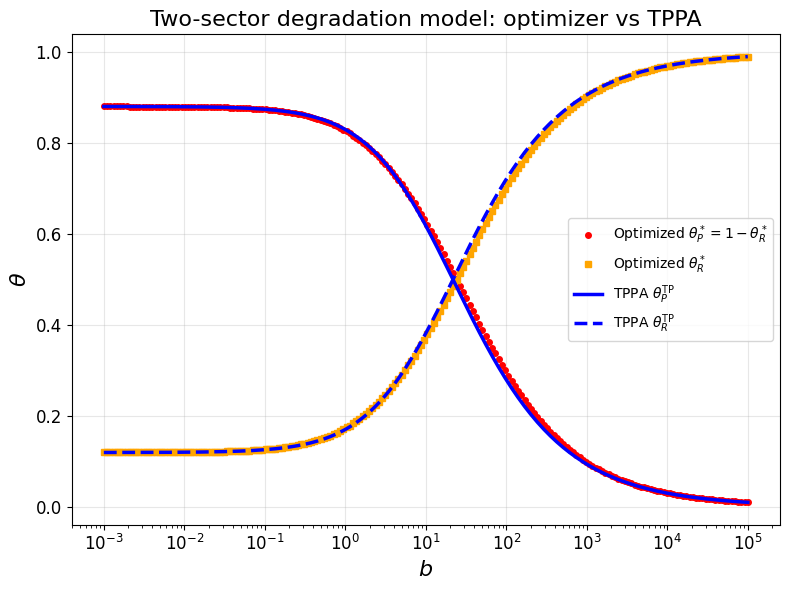

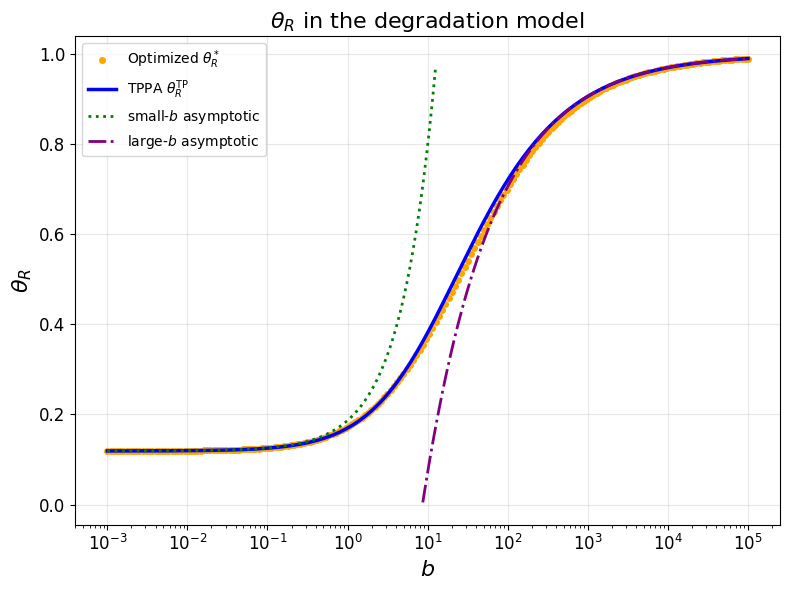

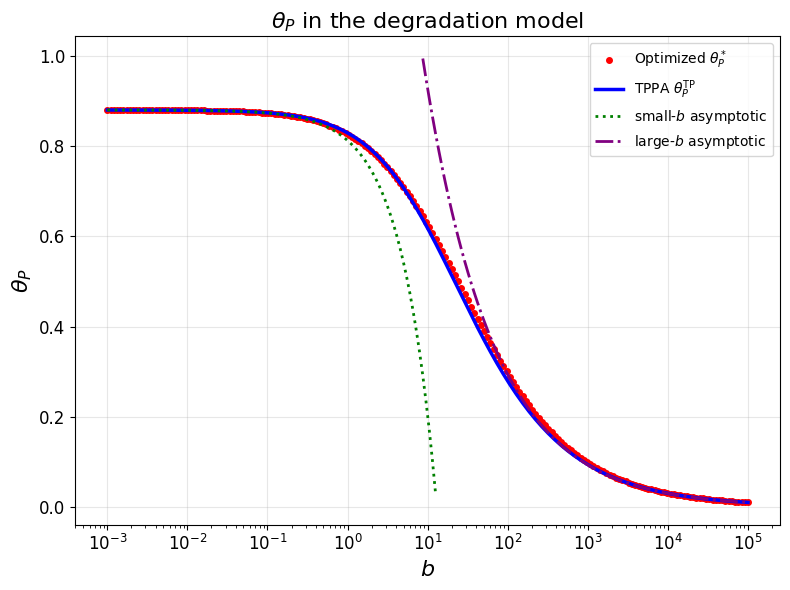

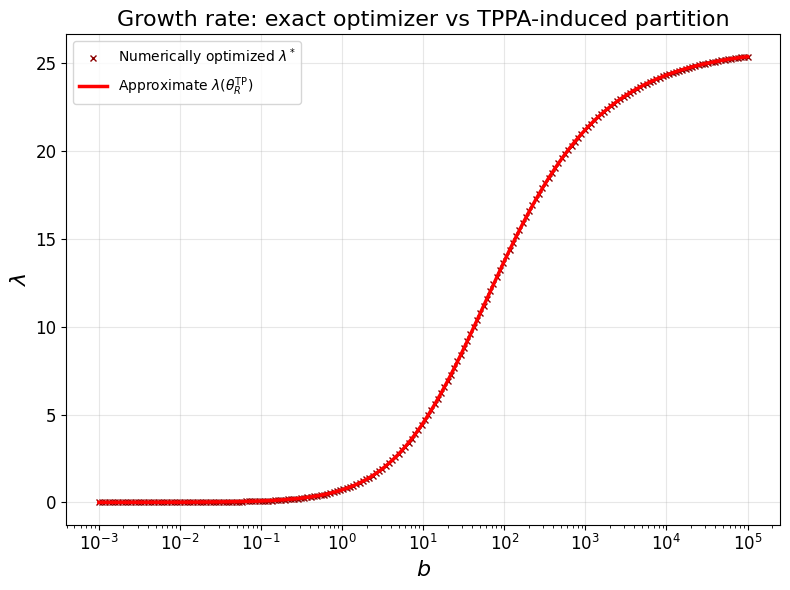

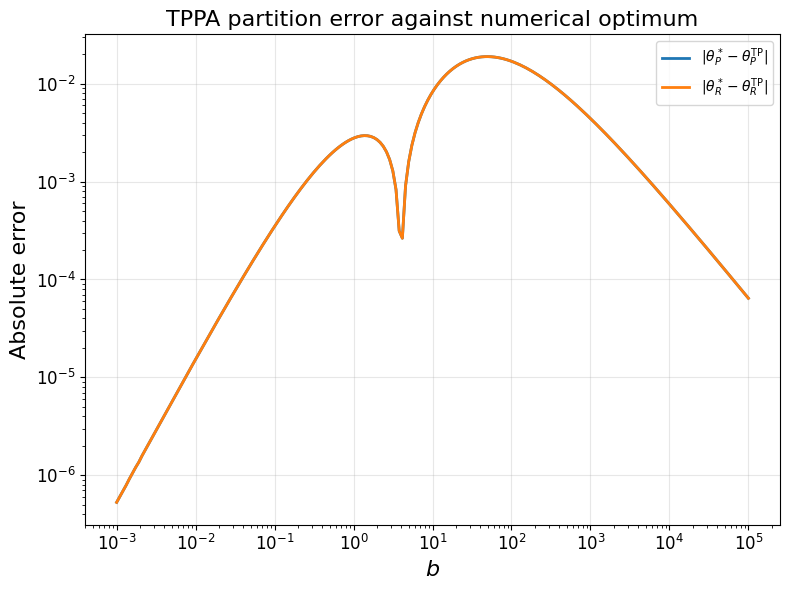

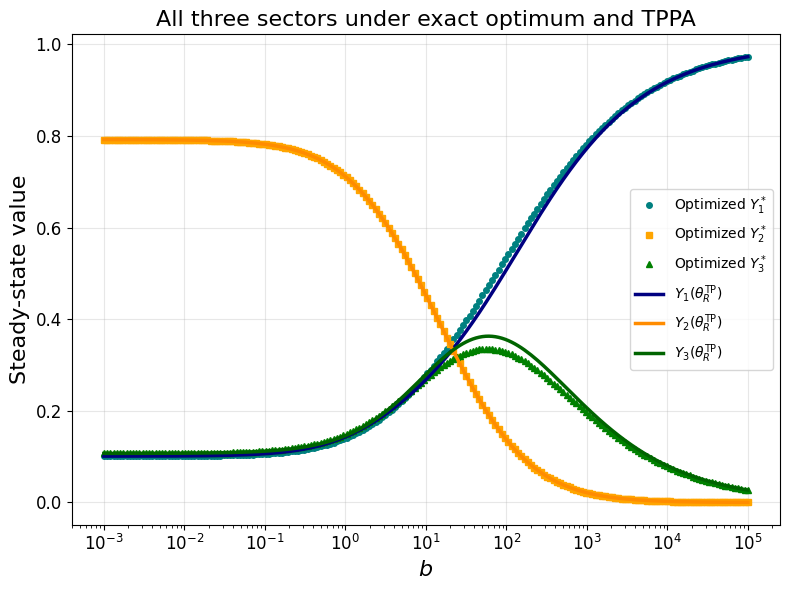

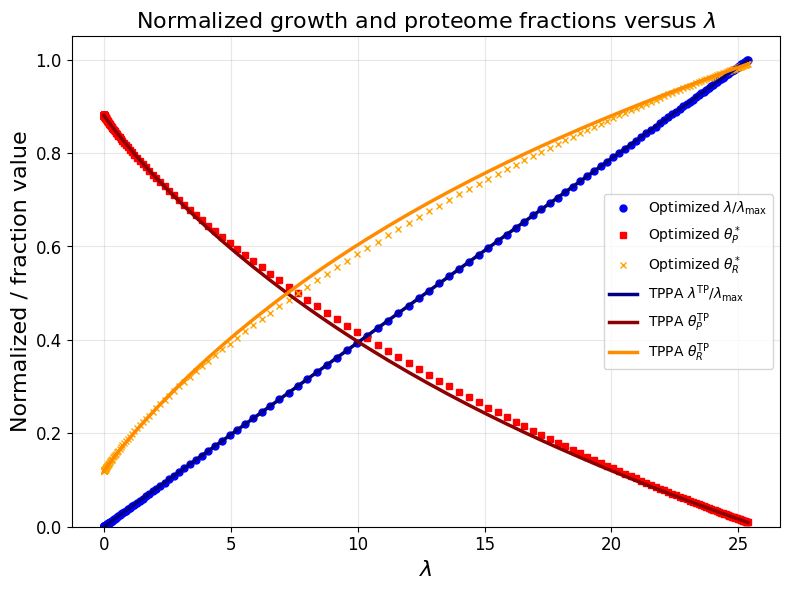

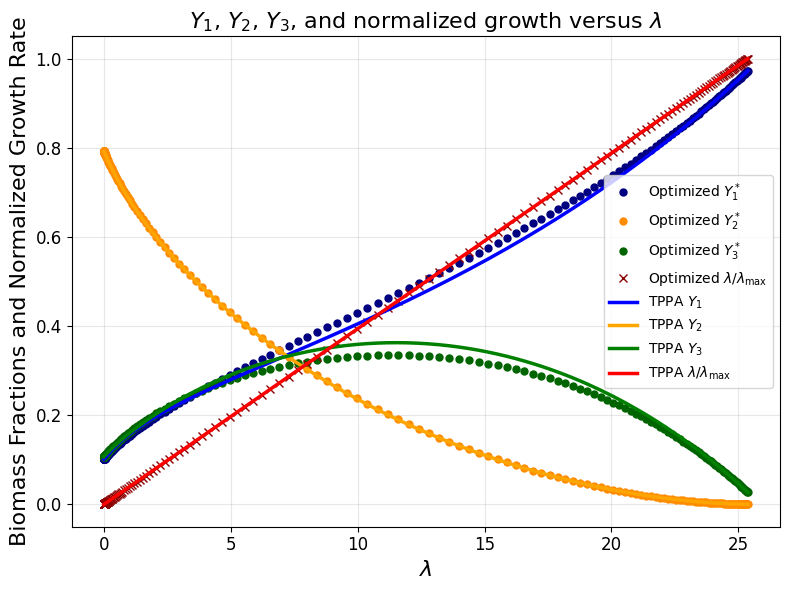

In [36]:
# ============================================================
# Plot 1: optimized partition vs TPPA
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^* = 1-\theta_R^*$', color='red')
plt.plot(b_arr, theta_arr, 's', ms=4, label=r'Optimized $\theta_R^*$', color='orange')

plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'TPPA $\theta_P^{\mathrm{TP}}$', color='blue')
plt.plot(b_arr, theta_TP_arr, '--', lw=2.5, label=r'TPPA $\theta_R^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta$', fontsize=label_size)
plt.title(r'Two-sector degradation model: optimizer vs TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: theta_R only, with asymptotic curves
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, theta_arr, 'o', ms=4, label=r'Optimized $\theta_R^*$', color='orange')
plt.plot(b_arr, theta_TP_arr, '-', lw=2.5, label=r'TPPA $\theta_R^{\mathrm{TP}}$', color='blue')
plt.plot(b_arr, theta_small_arr, ':', lw=2.0, label=r'small-$b$ asymptotic', color='green')
plt.plot(b_arr, theta_large_arr, '-.', lw=2.0, label=r'large-$b$ asymptotic', color='purple')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_R$', fontsize=label_size)
plt.title(r'$\theta_R$ in the degradation model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: theta_P only, with asymptotic curves
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^*$', color='red')
plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'TPPA $\theta_P^{\mathrm{TP}}$', color='blue')
plt.plot(b_arr, 1-theta_small_arr, ':', lw=2.0, label=r'small-$b$ asymptotic', color='green')
plt.plot(b_arr, 1-theta_large_arr, '-.', lw=2.0, label=r'large-$b$ asymptotic', color='purple')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_P$', fontsize=label_size)
plt.title(r'$\theta_P$ in the degradation model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: exact optimized growth rate vs TPPA-induced growth rate
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, lambda_arr, 'x', ms=4, label=r'Numerically optimized $\lambda^*$', color='darkred')
plt.plot(b_arr, lambda_TP_arr, '-', lw=2.5,
         label=r'Approximate $\lambda(\theta_R^{\mathrm{TP}})$', color='red')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'Growth rate: exact optimizer vs TPPA-induced partition', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5: TPPA partition error against numerical optimum
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_abs_err, lw=2, label=r'$|\theta_P^*-\theta_P^{\mathrm{TP}}|$')
plt.plot(b_arr, theta_abs_err, lw=2, label=r'$|\theta_R^*-\theta_R^{\mathrm{TP}}|$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'Absolute error', fontsize=label_size)
plt.title(r'TPPA partition error against numerical optimum', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 6: all three sectors Y1, Y2, Y3 under optimum vs TPPA
# ============================================================
plt.figure(figsize=(8, 6))

# Optimized points
plt.plot(b_arr, Y1_arr, 'o', ms=4, label=r'Optimized $Y_1^*$', color='teal')
plt.plot(b_arr, Y2_arr, 's', ms=4, label=r'Optimized $Y_2^*$', color='orange')
plt.plot(b_arr, Y3_arr, '^', ms=4, label=r'Optimized $Y_3^*$', color='green')

# TPPA-induced curves
plt.plot(b_arr, Y1_TP_arr, '-', lw=2.5, label=r'$Y_1(\theta_R^{\mathrm{TP}})$', color='navy')
plt.plot(b_arr, Y2_TP_arr, '-', lw=2.5, label=r'$Y_2(\theta_R^{\mathrm{TP}})$', color='darkorange')
plt.plot(b_arr, Y3_TP_arr, '-', lw=2.5, label=r'$Y_3(\theta_R^{\mathrm{TP}})$', color='darkgreen')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'Steady-state value', fontsize=label_size)
plt.title(r'All three sectors under exact optimum and TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 7: normalized lambda, theta_P, theta_R versus lambda
#         with TPPA overlays
# ============================================================
lam_ref = np.max(lambda_arr)

lambda_norm_arr = lambda_arr / np.maximum(lam_ref, 1e-14)
lambda_TP_norm_arr = lambda_TP_arr / np.maximum(lam_ref, 1e-14)

# Sort by lambda for clean curves
idx_opt = np.argsort(lambda_arr)
idx_tp = np.argsort(lambda_TP_arr)

plt.figure(figsize=(8, 6))

# Optimized curves
plt.plot(lambda_arr[idx_opt], lambda_norm_arr[idx_opt], 'o', ms=5, lw=2,
         label=r'Optimized $\lambda/\lambda_{\max}$', color='blue')
plt.plot(lambda_arr[idx_opt], thetaP_arr[idx_opt], 's', ms=5, lw=2,
         label=r'Optimized $\theta_P^*$', color='red')
plt.plot(lambda_arr[idx_opt], theta_arr[idx_opt], 'x', ms=5, lw=2,
         label=r'Optimized $\theta_R^*$', color='orange')

# TPPA-induced curves
plt.plot(lambda_TP_arr[idx_tp], lambda_TP_norm_arr[idx_tp], '-', lw=2.5,
         label=r'TPPA $\lambda^{\mathrm{TP}}/\lambda_{\max}$', color='navy')
plt.plot(lambda_TP_arr[idx_tp], thetaP_TP_arr[idx_tp], '-', lw=2.5,
         label=r'TPPA $\theta_P^{\mathrm{TP}}$', color='darkred')
plt.plot(lambda_TP_arr[idx_tp], theta_TP_arr[idx_tp], '-', lw=2.5,
         label=r'TPPA $\theta_R^{\mathrm{TP}}$', color='darkorange')

plt.xlabel(r'$\lambda$', fontsize=label_size)
plt.ylabel(r'Normalized / fraction value', fontsize=label_size)
plt.title(r'Normalized growth and proteome fractions versus $\lambda$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 8: Y1, Y2, Y3, normalized lambda versus lambda
#       with TPPA overlays
# ============================================================
lam_ref = np.max(lambda_arr)

lambda_norm_arr = lambda_arr / np.maximum(lam_ref, 1e-14)
lambda_TP_norm_arr = lambda_TP_arr / np.maximum(lam_ref, 1e-14)

# Sort by lambda for clean curves
idx_opt = np.argsort(lambda_arr)
idx_tp = np.argsort(lambda_TP_arr)

plt.figure(figsize=(8, 6))

# Optimized points
plt.plot(lambda_arr[idx_opt], Y1_arr[idx_opt], 'o', ms=5,
         color='navy', label=r'Optimized $Y_1^*$')
plt.plot(lambda_arr[idx_opt], Y2_arr[idx_opt], 'o', ms=5,
         color='darkorange', label=r'Optimized $Y_2^*$')
plt.plot(lambda_arr[idx_opt], Y3_arr[idx_opt], 'o', ms=5,
         color='darkgreen', label=r'Optimized $Y_3^*$')
plt.plot(lambda_arr[idx_opt], lambda_norm_arr[idx_opt], 'x', ms=6,
         color='darkred', label=r'Optimized $\lambda/\lambda_{\max}$')

# TPPA lines
plt.plot(lambda_TP_arr[idx_tp], Y1_TP_arr[idx_tp], '-', lw=2.5,
         color='blue', label=r'TPPA $Y_1$')
plt.plot(lambda_TP_arr[idx_tp], Y2_TP_arr[idx_tp], '-', lw=2.5,
         color='orange', label=r'TPPA $Y_2$')
plt.plot(lambda_TP_arr[idx_tp], Y3_TP_arr[idx_tp], '-', lw=2.5,
         color='green', label=r'TPPA $Y_3$')
plt.plot(lambda_TP_arr[idx_tp], lambda_TP_norm_arr[idx_tp], '-', lw=2.5,
         color='red', label=r'TPPA $\lambda/\lambda_{\max}$')

plt.xlabel(r'$\lambda$', fontsize=label_size)
plt.ylabel(r'Biomass Fractions and Normalized Growth Rate', fontsize=label_size)
plt.title(r'$Y_1$, $Y_2$, $Y_3$, and normalized growth versus $\lambda$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()